In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("abalone.csv")
print(df.shape)
df.head()

(4177, 9)


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


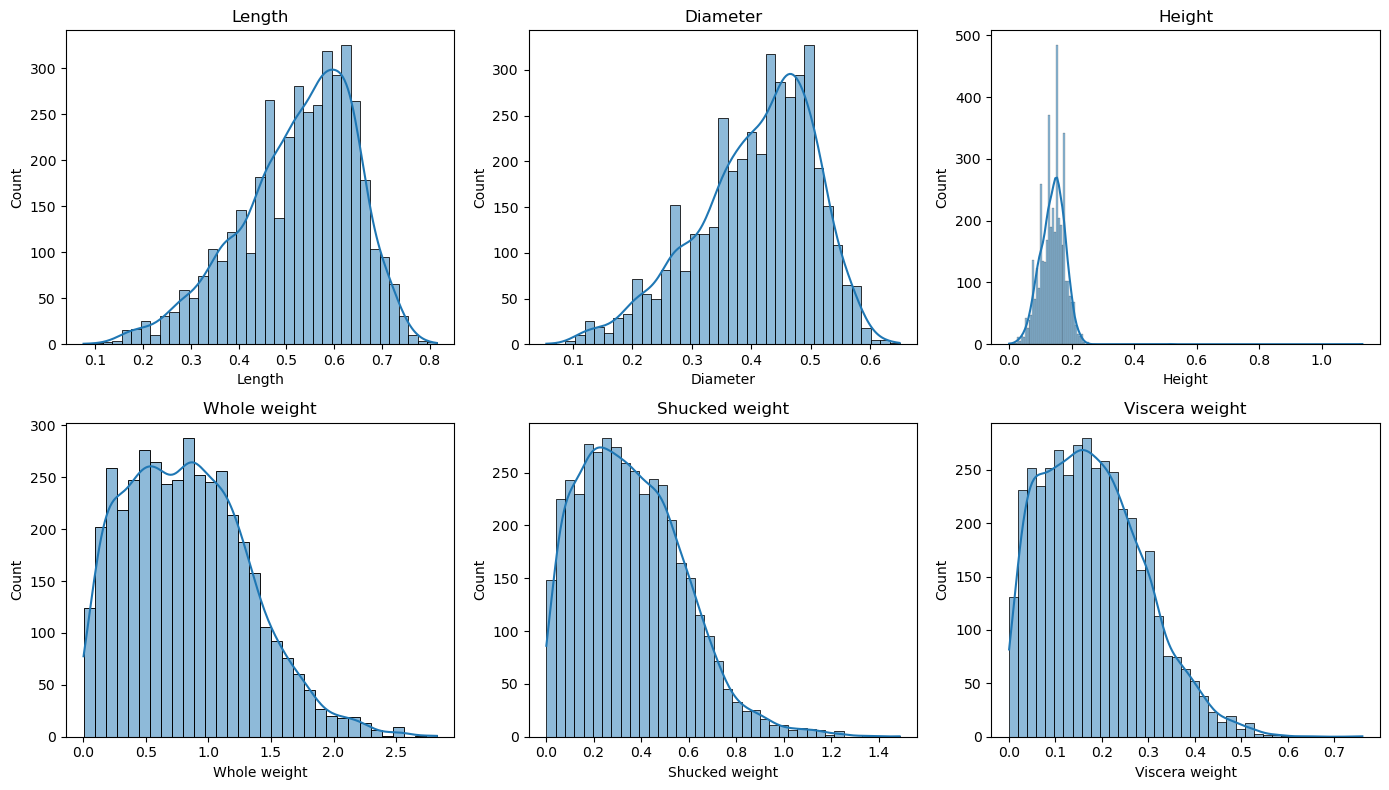

In [ ]:
# EDA
df.info()
df.describe(include='all').T

df.isna().sum().sort_values(ascending=False)

num_df = df.select_dtypes(include=[np.number])
num_df.corr().style.background_gradient(cmap='coolwarm')
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, col in zip(axes, num_df.columns[:6]):
    sns.histplot(num_df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
df['target'] = (df['Rings'] >= 10).astype(int)
df = pd.get_dummies(df, columns=['Sex'], drop_first=True)
X = df.drop(columns=['Rings', 'target'])
y = df['target']

print("Features shape:", X.shape, "Target positive rate:", y.mean().round(3))

Features shape: (4177, 9) Target positive rate: 0.498


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=500, n_jobs=-1)
log_reg.fit(X_train_std, y_train)

y_pred = log_reg.predict(X_test_std)
print("Logistic Regression — Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Logistic Regression — Accuracy: 0.784688995215311
Confusion Matrix:
 [[339  81]
 [ 99 317]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.81      0.79       420
           1       0.80      0.76      0.78       416

    accuracy                           0.78       836
   macro avg       0.79      0.78      0.78       836
weighted avg       0.79      0.78      0.78       836



PCA explained variance ratio:
[7.57032358e-01 1.26170231e-01 4.48973696e-02 3.14813475e-02
 1.85509274e-02 1.27196838e-02 7.10699497e-03 1.37375110e-03
 6.67337273e-04]


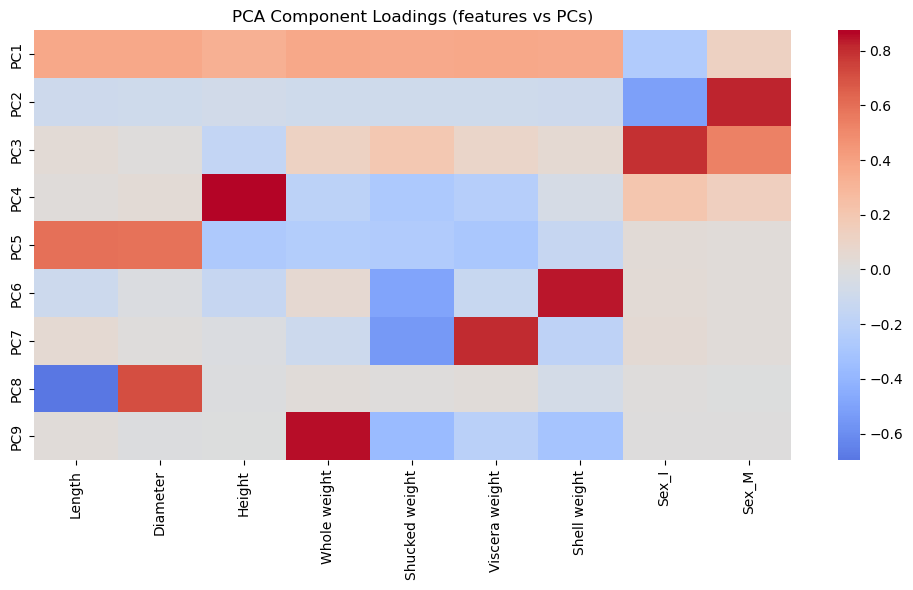

In [ ]:
pca = PCA(n_components=None, random_state=42)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

print("PCA explained variance ratio:")
print(pca.explained_variance_ratio_)

components_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)
sns.heatmap(components_df, cmap='coolwarm', center=0)
plt.show()

In [ ]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = int(np.searchsorted(cum_var, 0.95) + 1)
print(f"PCs to cover 95% variance: {n_components_95}")

pca_95 = PCA(n_components=n_components_95, random_state=42)
X_train_pca95 = pca_95.fit_transform(X_train_std)
X_test_pca95 = pca_95.transform(X_test_std)

log_pca = LogisticRegression(max_iter=500, n_jobs=-1)
log_pca.fit(X_train_pca95, y_train)
yp_log_pca = log_pca.predict(X_test_pca95)
print("LogReg (PCs) — Accuracy:", accuracy_score(y_test, yp_log_pca))
print("Confusion Matrix:\n", confusion_matrix(y_test, yp_log_pca))
print("Classification Report:\n", classification_report(y_test, yp_log_pca))

svc = SVC(kernel='rbf', gamma='scale')
svc.fit(X_train_pca95, y_train)
yp_svc = svc.predict(X_test_pca95)
print("SVC (PCs) — Accuracy:", accuracy_score(y_test, yp_svc))
print("Confusion Matrix:\n", confusion_matrix(y_test, yp_svc))
print("Classification Report:\n", classification_report(y_test, yp_svc))

PCs to cover ~95% variance: 4
LogReg (PCs) — Accuracy: 0.7404306220095693
Confusion Matrix:
 [[305 115]
 [102 314]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.73      0.74       420
           1       0.73      0.75      0.74       416

    accuracy                           0.74       836
   macro avg       0.74      0.74      0.74       836
weighted avg       0.74      0.74      0.74       836

LogReg (PCs) — Accuracy: 0.7404306220095693
Confusion Matrix:
 [[305 115]
 [102 314]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.73      0.74       420
           1       0.73      0.75      0.74       416

    accuracy                           0.74       836
   macro avg       0.74      0.74      0.74       836
weighted avg       0.74      0.74      0.74       836

SVC (PCs) — Accuracy: 0.7356459330143541
Confusion Matrix:
 [[272 148]
 [ 73 343]]
Classificatio